# Control de un grado de libertad (1-GDL) por asignación de polos

En este notebook se diseña un controlador de **un grado de libertad** para una planta de segundo orden, ubicando los polos de lazo cerrado mediante el método lineal algebraico (función `cont1dof` de `DCMotor`).

Se analizan:

1. la respuesta al escalón de la **salida** $y(t)$ y sus especificaciones (sobrepaso, tiempo de establecimiento, etc.);
2. la **señal de control** $u(t)$ que el controlador aplica a la planta;
3. el efecto de incluir, o no, **acción integral** en el controlador.

> Este notebook es solo de simulación: no requiere la plataforma DCMotor conectada.

In [15]:
using DCMotor
using Plots

## 1. Modelo de la planta

Se usa como ejemplo la planta de segundo orden

$$G(s) = \frac{3}{s^2 + 4s + 3} = \frac{3}{(s+1)(s+3)},$$

de orden $n = 2$, con polos en $s=-1$ y $s=-3$.


In [16]:
s = tf("s")
G = 3/(s^2 + 4s + 3)  # función de transferencia de la planta

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Int64}}
     3
------------
s^2 + 4s + 3

Continuous-time transfer function model

## 2. Diseño del controlador

El lazo de control es de realimentación unitaria:

$$u = C(s)\,\big(r - y\big), \qquad T(s) = \frac{C(s)\,G(s)}{1 + C(s)\,G(s)}.$$

La función `cont1dof(G, polos)` calcula el controlador $C(s)$ que hace que los polos de $T(s)$ sean exactamente los del vector `polos`. Para una planta de orden $n$ se necesitan **al menos $2n-1$ polos**:

- con $2n-1$ polos, el controlador es de orden $n-1$ y **no** incluye acción integral;
- con $2n$ o más polos, el controlador sube de orden y `cont1dof` le **agrega acción integral** automáticamente.

Aquí $n=2$ y se eligen $2n-1 = 3$ polos:

- un par dominante en $-4 \pm 2j$, que corresponde a $\omega_n = \sqrt{4^2+2^2} \approx 4.47$ rad/s y $\zeta = 4/\omega_n \approx 0.89$.
- un polo rápido en $-12$

In [17]:
polos_lc = [-4+2im, -4-2im, -12]
C = cont1dof(G, polos_lc)   # controlador 1-GDL

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
16.333333333333332s + 64.0
--------------------------
       1.0s + 16.0

Continuous-time transfer function model

In [18]:
T = feedback(C*G, 1)        # sistema en lazo cerrado de r a y

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
          49.0s + 192.0
---------------------------------
1.0s^3 + 20.0s^2 + 116.0s + 240.0

Continuous-time transfer function model

## 3. Respuesta al escalón y especificaciones

`stepinfo` calcula las especificaciones de la respuesta al escalón (sobrepaso, tiempo de subida, tiempo de establecimiento, valor final, etc.) y las muestra sobre la gráfica.

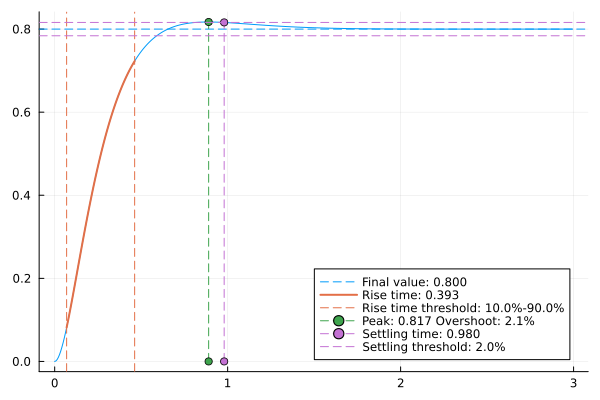

In [34]:
reference = 1
res = step(T*reference, 3)
plot(stepinfo(res))

## 4. Señal de control

Además de la salida, interesa conocer la **señal de control** $u(t)$, porque en  una planta real está limitada. La función de transferencia de la referencia a la señal de control es

$$G_{ur}(s) = \frac{U(s)}{R(s)} = \frac{T(s)}{G(s)},$$



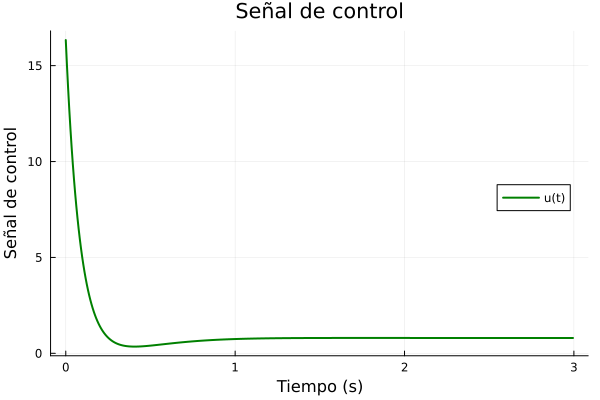

In [35]:
Gur = minreal(T/G)   # de r a u
t_final = 3
res_u = step(reference*Gur, t_final);


plot(res_u.t, vec(res_u.y), label="u(t)", xlabel="Tiempo (s)", ylabel="Señal de control",
             title="Señal de control", color=:green, linewidth=2, legend=:right)

## 5. Acción integral
Para quitar el error de estado estacionario debemos colocar un controlador de mayor orden, esto lo hacemos así: 

In [39]:
polos_2 = [-4+2im, -4-2im, -12, -12]
C2 = cont1dof(G, polos_2) 
T2 = feedback(G*C2, 1)  # controlador 1-GDL
print(C2)

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
80.33333333333333s^2 + 516.0s + 960.0
-------------------------------------
           1.0s^2 + 28.0s

Continuous-time transfer function model

## Respuesta del sistema

Con el controlador $C_2(s)$ la respuesta es la siguiente

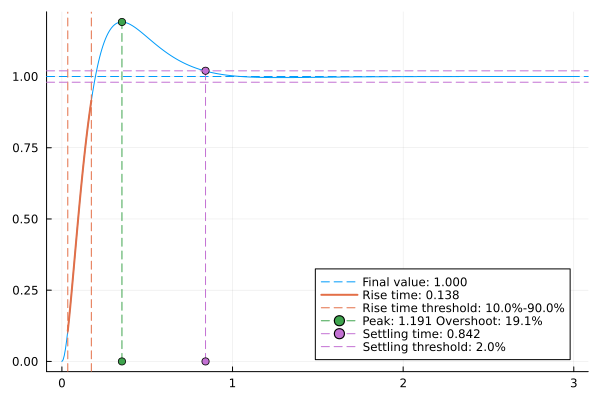

In [33]:
res = step(T2*reference, 3)
plot(stepinfo(res))

Notemos que hay más sobrepico, pero ya no hay error. 

### Señal de control
Con el controlador $C_2(s)$ que tiene efecto integral esta es la señal de control

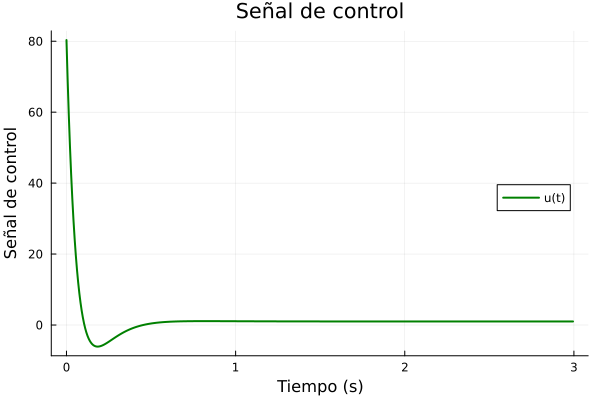

In [36]:
Gur2 = minreal(T2/G)   # de r a u
t_final = 3
res_u2 = step(reference*Gur2, t_final);

plot(res_u2.t, vec(res_u2.y), label="u(t)", xlabel="Tiempo (s)", ylabel="Señal de control",
             title="Señal de control", color=:green, linewidth=2, legend=:right)

**La señal de control es muicho mayor!**